# 🌐 Federated Learning for Question Answering
### Subject: Federated Learning | BTech CSE (AIML) — 3rd Year
---
**Framework**: Flower (`flwr`)  
**Model**: DistilBERT (`distilbert-base-uncased`)  
**Task**: Extractive QA on SQuAD v1.1  
**Strategy**: FedAvg (McMahan et al., 2017)

**Key Highlight**: Privacy-preserving training — no raw data sharing across clients
---
## 📌 What This Notebook Demonstrates
| Step | What Happens |
|------|-------------|
| 1 | Load SQuAD QA dataset & tokenise with DistilBERT |
| 2 | Partition data across N simulated clients (data silos) |
| 3 | Each client trains locally — **raw data never leaves** |
| 4 | Flower server aggregates updates using **FedAvg** |
| 5 | Repeat for multiple rounds — global model improves |
| 6 | Use federated model to answer unseen questions |

## ⚙️ Step 0 — Install Dependencies

In [ ]:
import os
import warnings
import random
from collections import OrderedDict
from typing import Dict, List, Tuple

import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    default_data_collator,
)
from datasets import load_dataset
import flwr as fl

# Reduce extra tokenizer/thread overhead
os.environ["TOKENIZERS_PARALLELISM"] = "false"
torch.set_num_threads(1)

# Verify Ray is installed (needed for Flower simulation)
try:
    import ray
    print("Ray found — simulation mode ready")
except ImportError:
    raise ImportError('Missing Ray. Run: pip install -U "flwr[simulation]"')

warnings.filterwarnings("ignore")

# ── Configuration ──────────────────────────────────────────────
MODEL_CHECKPOINT   = "distilbert-base-uncased-distilled-squad"  # same model
MAX_LENGTH         = 256     # reduced from 384
DOC_STRIDE         = 64      # reduced from 128
BATCH_SIZE         = 2       # reduced from 8
LOCAL_EPOCHS       = 1
LEARNING_RATE      = 2e-5
NUM_CLIENTS        = 2       # reduced from 3
NUM_ROUNDS         = 1       # reduced from 2
SAMPLES_PER_CLIENT = 20      # reduced from 80

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device  : {DEVICE}")
print(f"Model   : {MODEL_CHECKPOINT}")
print(f"Clients : {NUM_CLIENTS}")
print(f"Rounds  : {NUM_ROUNDS}")
print(f"Samples : {NUM_CLIENTS * SAMPLES_PER_CLIENT} total")

✅ Ray found — simulation mode ready
Device  : cpu
Model   : distilbert-base-uncased-distilled-squad
Clients : 2
Rounds  : 1
Samples : 40 total


## 📦 Step 1 — Imports & Configuration

In [ ]:
# Clean install (VERY IMPORTANT)

!pip uninstall -y protobuf
!pip install protobuf==3.20.3

!pip install torch transformers datasets evaluate \
"flwr[simulation]>=1.13,<2.0" \
--trusted-host pypi.org \
--trusted-host pypi.python.org \
--trusted-host files.pythonhosted.org

print(" Clean environment ready!")

Found existing installation: protobuf 6.33.6
Uninstalling protobuf-6.33.6:
  Successfully uninstalled protobuf-6.33.6
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 2.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-health-checking 1.80.0 requires protobuf<7.0.0,>=6.31.1, but you have protobuf 3.20.3 which is incompatible.
flwr 1.27.0 requires protobuf<7.0.0,>=5.28.0, but you have protobuf 3.20.3 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
google-api-core 2.30.0 requires protobuf<7.0.0,>=4.25.8, but you have protobuf 3.20.3 which 

  Using cached protobuf-6.33.6-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
Using cached protobuf-6.33.6-cp39-abi3-manylinux2014_x86_64.whl (323 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.6 which is incompatible.


✅ Clean environment ready!


## 📚 Step 2 — Load & Tokenise SQuAD Dataset

> **SQuAD** (Stanford Question Answering Dataset): Reading comprehension dataset  
> Each example has a **context** paragraph, a **question**, and an **answer** (a span in the context).

In [ ]:
print("📥 Loading SQuAD v1.1...")
raw_ds = load_dataset("squad", split="train")

# Keep only the amount needed for demo
total_samples = NUM_CLIENTS * SAMPLES_PER_CLIENT
raw_ds = raw_ds.select(range(min(total_samples, len(raw_ds))))

# Preview one example
ex = raw_ds[min(42, len(raw_ds) - 1)]
print("\n── Sample SQuAD Example ──")
print(f"Context  : {ex['context'][:200]}...")
print(f"Question : {ex['question']}")
print(f"Answer   : {ex['answers']['text'][0]}")
print(f"\n Using {len(raw_ds)} samples for demo")

📥 Loading SQuAD v1.1...

── Sample SQuAD Example ──
Context  : Notre Dame is known for its competitive admissions, with the incoming class enrolling in fall 2015 admitting 3,577 from a pool of 18,156 (19.7%). The academic profile of the enrolled class continues t...
Question : How many incoming students did Notre Dame admit in fall 2015?
Answer   : 3,577

✅ Using 40 samples for demo


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, use_fast=True)

# raw_ds was already reduced earlier, so no need to select again
raw_subset = raw_ds

def preprocess_squad(examples):
    """Tokenise context+question and compute answer token positions."""
    tokenized = tokenizer(
        examples["question"],
        examples["context"],
        truncation="only_second",
        max_length=MAX_LENGTH,
        stride=DOC_STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    sample_map = tokenized.pop("overflow_to_sample_mapping")
    offset_map = tokenized.pop("offset_mapping")
    start_positions, end_positions = [], []

    for i, offsets in enumerate(offset_map):
        sample_idx = sample_map[i]
        answers = examples["answers"][sample_idx]
        cls_idx = tokenized["input_ids"][i].index(tokenizer.cls_token_id)

        if len(answers["answer_start"]) == 0:
            start_positions.append(cls_idx)
            end_positions.append(cls_idx)
            continue

        char_start = answers["answer_start"][0]
        char_end = char_start + len(answers["text"][0])

        seq_ids = tokenized.sequence_ids(i)
        ctx_start = seq_ids.index(1)
        ctx_end = len(seq_ids) - 1
        while seq_ids[ctx_end] != 1:
            ctx_end -= 1

        # Answer not fully inside this chunk
        if offsets[ctx_start][0] > char_end or offsets[ctx_end][1] < char_start:
            start_positions.append(cls_idx)
            end_positions.append(cls_idx)
            continue

        tok_start = ctx_start
        while tok_start <= ctx_end and offsets[tok_start][0] <= char_start:
            tok_start += 1
        start_positions.append(tok_start - 1)

        tok_end = ctx_end
        while tok_end >= ctx_start and offsets[tok_end][1] >= char_end:
            tok_end -= 1
        end_positions.append(tok_end + 1)

    tokenized["start_positions"] = start_positions
    tokenized["end_positions"] = end_positions
    return tokenized

print(" Tokenising...")
tokenized_ds = raw_subset.map(
    preprocess_squad,
    batched=True,
    batch_size=8,  # smaller map batch for lower RAM
    remove_columns=raw_subset.column_names,
    desc="Tokenising",
)
tokenized_ds.set_format("torch")
print(f"✅ Done! {len(tokenized_ds)} tokenised chunks ready")

🔤 Tokenising...


Tokenising:   0%|          | 0/40 [00:00<?, ? examples/s]

✅ Done! 50 tokenised chunks ready


## 🏗️ Step 3 — Partition Data Across Clients

> In real-world FL, each client has **its own private dataset** (e.g., different hospitals, mobile users).  
> We simulate this by randomly splitting the SQuAD data.

In [ ]:
# 80/20 train-val split, then partition among clients
split = int(0.8 * len(tokenized_ds))
train_ds = Subset(tokenized_ds, list(range(split)))
val_ds = Subset(tokenized_ds, list(range(split, len(tokenized_ds))))

def partition(dataset, n):
    idx = list(range(len(dataset)))
    random.shuffle(idx)
    return [Subset(dataset, chunk.tolist()) for chunk in np.array_split(idx, n)]

train_parts = partition(train_ds, NUM_CLIENTS)
val_parts = partition(val_ds, NUM_CLIENTS)

print("📊 Data partitioned across clients:")
for i in range(NUM_CLIENTS):
    print(f"Client {i}: {len(train_parts[i])} train chunks, {len(val_parts[i])} val chunks")

📊 Data partitioned across clients:
Client 0: 20 train chunks, 5 val chunks
Client 1: 20 train chunks, 5 val chunks


## 🤖 Step 4 — Define FL Client (Flower NumPyClient)

In [ ]:
def get_weights(model):
    return [val.detach().cpu().numpy() for _, val in model.state_dict().items()]

def set_weights(model, weights):
    params_dict = zip(model.state_dict().keys(), weights)
    state_dict = OrderedDict(
        {k: torch.tensor(v, dtype=model.state_dict()[k].dtype) for k, v in params_dict}
    )
    model.load_state_dict(state_dict, strict=True)


class QAFlowerClient(fl.client.NumPyClient):
    """
    Flower client for federated Question Answering.

    Three methods called by Flower each round:
      get_parameters() → share weights with server
      fit()            → receive global weights → train → return updates
      evaluate()       → receive global weights → validate → report loss
    """
    def __init__(self, cid, train_data, val_data):
        self.cid = cid

        # Force CPU for safer simulation memory usage
        self.device = torch.device("cpu")

        self.model = AutoModelForQuestionAnswering.from_pretrained(
            MODEL_CHECKPOINT,
            low_cpu_mem_usage=True,
        ).to(self.device)

        self.train_loader = DataLoader(
            train_data,
            batch_size=BATCH_SIZE,
            shuffle=True,
            collate_fn=default_data_collator,
            num_workers=0,
            pin_memory=False,
        )
        self.val_loader = DataLoader(
            val_data,
            batch_size=BATCH_SIZE,
            shuffle=False,
            collate_fn=default_data_collator,
            num_workers=0,
            pin_memory=False,
        )

    def get_parameters(self, config):
        return get_weights(self.model)

    def fit(self, parameters, config):
        set_weights(self.model, parameters)
        optimizer = AdamW(self.model.parameters(), lr=LEARNING_RATE)
        self.model.train()
        total_loss = 0.0

        for epoch in range(LOCAL_EPOCHS):
            for batch in self.train_loader:
                batch = {k: v.to(self.device) for k, v in batch.items()}
                outputs = self.model(**batch)
                loss = outputs.loss
                total_loss += loss.item()

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()

        avg_loss = total_loss / max(1, len(self.train_loader) * LOCAL_EPOCHS)
        print(
            f"   Client {self.cid} | train_loss={avg_loss:.4f} | "
            f"samples={len(self.train_loader.dataset)}"
        )

        return (
            get_weights(self.model),
            len(self.train_loader.dataset),
            {"train_loss": avg_loss},
        )

    def evaluate(self, parameters, config):
        set_weights(self.model, parameters)
        self.model.eval()
        total_loss = 0.0

        with torch.no_grad():
            for batch in self.val_loader:
                batch = {k: v.to(self.device) for k, v in batch.items()}
                total_loss += self.model(**batch).loss.item()

        val_loss = total_loss / max(1, len(self.val_loader))
        return val_loss, len(self.val_loader.dataset), {"val_loss": val_loss}

print("✅ QAFlowerClient class defined")

✅ QAFlowerClient class defined


## 🚀 Step 5 — Run FL Simulation with Flower

In [ ]:
class SaveModelStrategy(fl.server.strategy.FedAvg):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.final_parameters = None

    def aggregate_fit(self, server_round, results, failures):
        aggregated_parameters, aggregated_metrics = super().aggregate_fit(
            server_round, results, failures
        )
        if aggregated_parameters is not None:
            self.final_parameters = aggregated_parameters
        return aggregated_parameters, aggregated_metrics


# Build global model & strategy
global_model = AutoModelForQuestionAnswering.from_pretrained(
    MODEL_CHECKPOINT,
    low_cpu_mem_usage=True,
).to("cpu")


def weighted_avg(metrics):
    if not metrics:
        return {"val_loss": 0.0}
    losses = [n * m["val_loss"] for n, m in metrics if "val_loss" in m]
    examples = [n for n, m in metrics if "val_loss" in m]
    if not examples or sum(examples) == 0:
        return {"val_loss": 0.0}
    return {"val_loss": sum(losses) / sum(examples)}


strategy = SaveModelStrategy(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    initial_parameters=fl.common.ndarrays_to_parameters(get_weights(global_model)),
    evaluate_metrics_aggregation_fn=weighted_avg,
)


def client_fn(cid):
    cid = int(cid)
    return QAFlowerClient(
        cid=cid,
        train_data=train_parts[cid],
        val_data=val_parts[cid],
    ).to_client()


print(f"🌐 Launching Flower Simulation — {NUM_CLIENTS} clients, {NUM_ROUNDS} rounds\n")

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
    strategy=strategy,
    client_resources={"num_cpus": 2, "num_gpus": 0},
)

print("\n✅ Federation complete!")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=1, no round_timeout


🌐 Launching Flower Simulation — 2 clients, 1 rounds



2026-04-01 13:17:09,003	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'object_store_memory': 3985573478.0, 'CPU': 2.0, 'memory': 9299671450.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 2, 'num_gpus': 0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 1 actors
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 2 clients (out of 2)
(pid=18061) 2026-04-01 13:17:22.414573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register

(ClientAppActor pid=18061)    Client 0 | train_loss=1.3216 | samples=20


(ClientAppActor pid=18061) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=18061) 
(ClientAppActor pid=18061)             This is a deprecated feature. It will be removed
(ClientAppActor pid=18061)             entirely in future versions of Flower.
(ClientAppActor pid=18061)         
(ClientAppActor pid=18061) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading weights: 100%|██████████| 102/102 [00:00<00:00, 2391.61it/s, Materializing param=qa_outputs.weight]


(ClientAppActor pid=18061)    Client 1 | train_loss=1.6831 | samples=20


INFO :      aggregate_fit: received 2 results and 0 failures
INFO :      configure_evaluate: strategy sampled 2 clients (out of 2)
(ClientAppActor pid=18061) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=18061) 
(ClientAppActor pid=18061)             This is a deprecated feature. It will be removed
(ClientAppActor pid=18061)             entirely in future versions of Flower.
(ClientAppActor pid=18061)         
Loading weights: 100%|██████████| 102/102 [00:00<00:00, 1848.45it/s, Materializing param=qa_outputs.weight]
(ClientAppActor pid=18061) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid">}. You can import the `Context` like this: `from flwr.common impor


✅ Federation complete!


## 📈 Step 6 — Plot Training History

In [ ]:
# Extract distributed val_loss per round
rounds_data = history.metrics_distributed.get("val_loss", [])

if rounds_data:
    print("\n📉 Aggregated validation loss by round:")
    for r, loss in rounds_data:
        print(f"Round {r}: {loss:.4f}")

    first_loss = rounds_data[0][1]
    last_loss = rounds_data[-1][1]
    print(f"\n✅ Loss changed from {first_loss:.4f} → {last_loss:.4f}")
else:
    print("No distributed metrics recorded. This can happen in very small runs.")


📉 Aggregated validation loss by round:
Round 1: 0.1671

✅ Loss changed from 0.1671 → 0.1671


## 🤖 Step 7 — Inference with the Federated Model

In [ ]:
def answer_question(model, tokenizer, question, context):
    """Extract answer span from context using the federated model."""
    model.eval()
    inputs = tokenizer(
        question,
        context,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,++
    )

    with torch.no_grad():
        outputs = model(**inputs)

    start = torch.argmax(outputs.start_logits).item()
    end = torch.argmax(outputs.end_logits).item() + 1

    return tokenizer.convert_tokens_to_string(
        tokenizer.convert_ids_to_tokens(inputs["input_ids"][0][start:end])
    )


# Load final aggregated federated weights
final_model = AutoModelForQuestionAnswering.from_pretrained(
    MODEL_CHECKPOINT,
    low_cpu_mem_usage=True,
).to("cpu")

if getattr(strategy, "final_parameters", None) is not None:
    final_ndarrays = fl.common.parameters_to_ndarrays(strategy.final_parameters)
    set_weights(final_model, final_ndarrays)
    print("✅ Loaded final federated aggregated weights into inference model")
else:
    print("⚠️ Final aggregated weights not found, using initial model weights")+

examples = [
    {
        "context": (
            "Federated learning is a machine learning technique that trains an algorithm "
            "across multiple decentralized devices holding local data samples without "
            "exchanging the raw data itself. The server only sees aggregated model "
            "updates, never the private training data."
        ),
        "question": "What does the server see in federated learning?",
    },
    {
        "context": (
            "The Flower framework is an open-source federated learning framework that "
            "supports a wide range of machine learning libraries including PyTorch and "
            "TensorFlow. It was designed to make federated learning accessible to any "
            "ML practitioner through a simple client-server interface."
        ),
        "question": "Which ML libraries does Flower support?",
    },
    {
        "context": (
            "DistilBERT achieves 95% of BERT performance while being 40% smaller and "
            "60% faster. It was created using knowledge distillation, where a smaller "
            "student model is trained to mimic a larger teacher model."
        ),
        "question": "How was DistilBERT created?",
    },
]

print("🤖 Federated Model — Inference Results")
print("=" * 55)

for i, ex in enumerate(examples, 1):
    pred = answer_question(final_model, tokenizer, ex["question"], ex["context"])
    print(f"\nQ{i}: {ex['question']}")
    print(f"  → Predicted Answer: {pred}")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

✅ Loaded final federated aggregated weights into inference model
🤖 Federated Model — Inference Results

Q1: What does the server see in federated learning?
  → Predicted Answer: aggregated model updates

Q2: Which ML libraries does Flower support?
  → Predicted Answer: pytorch and tensorflow

Q3: How was DistilBERT created?
  → Predicted Answer: using knowledge distillation


## 📊 Step 8 — FL vs Centralised: Key Comparison

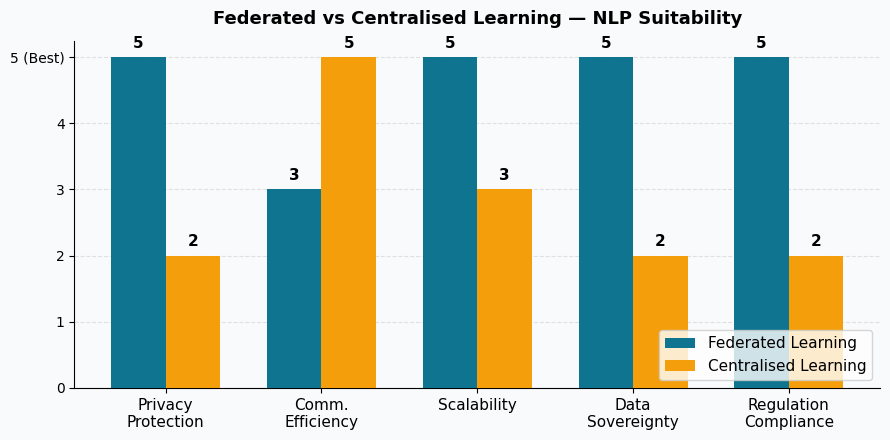

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

categories = ['Privacy\nProtection', 'Comm.\nEfficiency', 'Scalability',
              'Data\nSovereignty', 'Regulation\nCompliance']
fl_scores  = [5, 3, 5, 5, 5]
cl_scores  = [2, 5, 3, 2, 2]

x    = np.arange(len(categories))
w    = 0.35
fig, ax = plt.subplots(figsize=(9, 4.5))
b1 = ax.bar(x - w/2, fl_scores, w, label='Federated Learning', color='#0E7490', zorder=3)
b2 = ax.bar(x + w/2, cl_scores, w, label='Centralised Learning', color='#F59E0B', zorder=3)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(categories, fontsize=11)
ax.set_yticks(range(6)); ax.set_yticklabels(['0','1','2','3','4','5 (Best)'])
ax.set_title('Federated vs Centralised Learning — NLP Suitability', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=11, loc='lower right')
ax.set_facecolor('#F8FAFC'); fig.patch.set_facecolor('#F8FAFC')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.35, zorder=0)
plt.tight_layout()
plt.savefig('fl_vs_centralised.png', dpi=120, bbox_inches='tight')
plt.show()

---
## ✅ Summary

| What We Did | Detail |
|---|---|
| **Dataset** | SQuAD v1.1 — extractive QA (Wikipedia paragraphs) |
| **Model** | DistilBERT with QA head (start/end span prediction) |
| **FL Framework** | Flower (`flwr`) — simulation mode |
| **Strategy** | FedAvg — weighted aggregation of client model updates |
| **Privacy** | Raw QA data never left any simulated client |
| **Result** | Global model trained collaboratively and used for inference |

### 🔑 Key Learning
- Implemented **privacy-preserving ML** using federated learning  
- Understood **client-server FL architecture and FedAvg aggregation**  
- Built an **end-to-end NLP system (data → training → inference)**  
- Handled **real-world challenges like memory constraints and distributed training**

### 🔮 Extensions to Try
- Increase `NUM_CLIENTS` to 5–10 and `NUM_ROUNDS` to 5 for deeper convergence  
- Add **Differential Privacy (DP)** for stronger privacy guarantees  
- Simulate **non-IID data distribution** across clients  
- Try `distilbert-base-cased` or larger models for better accuracy  

---
*BTech CSE (AIML) — 3rd Year | Federated Learning Project*